# 🫀 CardioIA — Fase 4: CNN para Classificação de ECG

**FIAP — Inteligência Artificial Aplicada à Cardiologia**

Este notebook implementa a Fase 4 do projeto **CardioIA**, com foco em Visão Computacional para imagens médicas simuladas de ECG.

## Objetivos

- Carregar e organizar um dataset público de imagens de ECG.
- Aplicar pré-processamento: redimensionamento, normalização e divisão treino/validação/teste.
- Treinar uma **CNN simples do zero**.
- Treinar um modelo com **Transfer Learning**.
- Avaliar os modelos com acurácia, precisão, recall, F1-score e matriz de confusão.
- Gerar artefatos para o protótipo Flask da Fase 4.
- Apoiar a análise de governança, ética e viés do **IR ALÉM 1**.

> Aviso: este notebook é acadêmico e usa dados públicos/simulados. Os resultados não substituem avaliação médica.

## 1. Configuração do Ambiente

In [1]:
# Em Colab, execute esta célula se precisar instalar dependências.
# Em ambiente local, prefira instalar pelo requirements.txt da Fase 4.
!pip install -q tensorflow matplotlib seaborn scikit-learn pillow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponível: []


## 2. Configuração do Dataset

Dataset recomendado para esta entrega:

**ECG Images — Kaggle**  
Nome: `analiviafr/ecg-images`

Estrutura esperada mais comum após extrair:

```text
data/raw/ecg_images/
├── train/
│   ├── N/
│   ├── S/
│   ├── V/
│   ├── F/
│   └── Q/
└── test/
    ├── N/
    ├── S/
    ├── V/
    ├── F/
    └── Q/
```

Este notebook também aceita imagens dentro de subpastas internas, pois a contagem e visualização são recursivas.

In [3]:
# ============================================================
# CONFIGURAÇÕES PRINCIPAIS
# ============================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS_CNN = 5
EPOCHS_TRANSFER = 5

# Para testes rápidos, deixe True.
# Para entrega final com dataset completo, altere para False se tiver tempo/recursos.
USE_SMALL_DATASET = True
MAX_TRAIN_IMAGES_PER_CLASS = 600
MAX_TEST_IMAGES_PER_CLASS = 200

# Caminhos possíveis.
# O notebook tenta encontrar automaticamente a pasta correta.
DATASET_CANDIDATES = [
    Path("/content/ecg_images"),
    Path("/content/drive/MyDrive/ecg_images"),
    Path("../../../data/raw/ecg_images"),
    Path("../../../../data/raw/ecg_images"),
    Path("data/raw/ecg_images"),
]

OUTPUT_DIR = Path("../../../phases/fase04_cnn_ecg/outputs").resolve()
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

OUTPUT_DIR: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs
MODEL_DIR: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\models
FIGURE_DIR: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\figures


In [4]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_recursive(directory: Path) -> int:
    if not directory.exists():
        return 0
    return len([
        f for f in directory.rglob("*")
        if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS
    ])

def has_class_subdirs_with_images(directory: Path) -> bool:
    if not directory.exists() or not directory.is_dir():
        return False

    for child in directory.iterdir():
        if child.is_dir() and count_images_recursive(child) > 0:
            return True
    return False

def find_dataset_root(candidates):
    """Encontra a pasta do dataset, aceitando estruturas com train/test ou classes diretas."""
    checked = []

    for candidate in candidates:
        candidate = candidate.resolve()
        checked.append(candidate)

        if not candidate.exists():
            continue

        # Caso 1: candidate/train e candidate/test
        if (candidate / "train").exists() and has_class_subdirs_with_images(candidate / "train"):
            return candidate

        # Caso 2: candidate já contém classes diretamente
        if has_class_subdirs_with_images(candidate):
            return candidate

        # Caso 3: existe uma pasta interna que contém train/test
        for sub in candidate.rglob("*"):
            if sub.is_dir() and (sub / "train").exists() and has_class_subdirs_with_images(sub / "train"):
                return sub

    msg = "Dataset não encontrado. Caminhos verificados:\n"
    msg += "\n".join([f"- {p}" for p in checked])
    raise FileNotFoundError(msg)

DATA_ROOT = find_dataset_root(DATASET_CANDIDATES)

if (DATA_ROOT / "train").exists():
    TRAIN_DIR = DATA_ROOT / "train"
    TEST_DIR = DATA_ROOT / "test" if (DATA_ROOT / "test").exists() else None
else:
    TRAIN_DIR = DATA_ROOT
    TEST_DIR = None

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

DATA_ROOT: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\data\raw\ecg_images
TRAIN_DIR: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\data\raw\ecg_images\train
TEST_DIR: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\data\raw\ecg_images\test


In [5]:
def get_class_names(directory: Path):
    class_names = []
    for child in sorted(directory.iterdir()):
        if child.is_dir() and count_images_recursive(child) > 0:
            class_names.append(child.name)
    return class_names

classes = get_class_names(TRAIN_DIR)

if len(classes) == 0:
    print("Conteúdo encontrado em TRAIN_DIR:")
    for item in TRAIN_DIR.iterdir():
        print("DIR " if item.is_dir() else "FILE", "-", item.name)
    raise ValueError("Nenhuma classe com imagens foi encontrada dentro da pasta de treino.")

print("✓ Dataset encontrado!")
print("\nClasses disponíveis:")

summary = []
for cls in classes:
    train_count = count_images_recursive(TRAIN_DIR / cls)
    test_count = count_images_recursive(TEST_DIR / cls) if TEST_DIR and (TEST_DIR / cls).exists() else 0
    summary.append({"classe": cls, "treino": train_count, "teste": test_count})
    print(f" - {cls}: {train_count} treino | {test_count} teste")

df_summary = pd.DataFrame(summary)
df_summary

✓ Dataset encontrado!

Classes disponíveis:
 - F: 641 treino | 161 teste
 - N: 22122 treino | 13661 teste
 - Q: 6413 treino | 1608 teste
 - S: 2222 treino | 557 teste
 - V: 5780 treino | 1448 teste


,classe,treino,teste
0,F,641,161
1,N,22122,13661
2,Q,6413,1608
3,S,2222,557
4,V,5780,1448


## 3. Visualização de Amostras

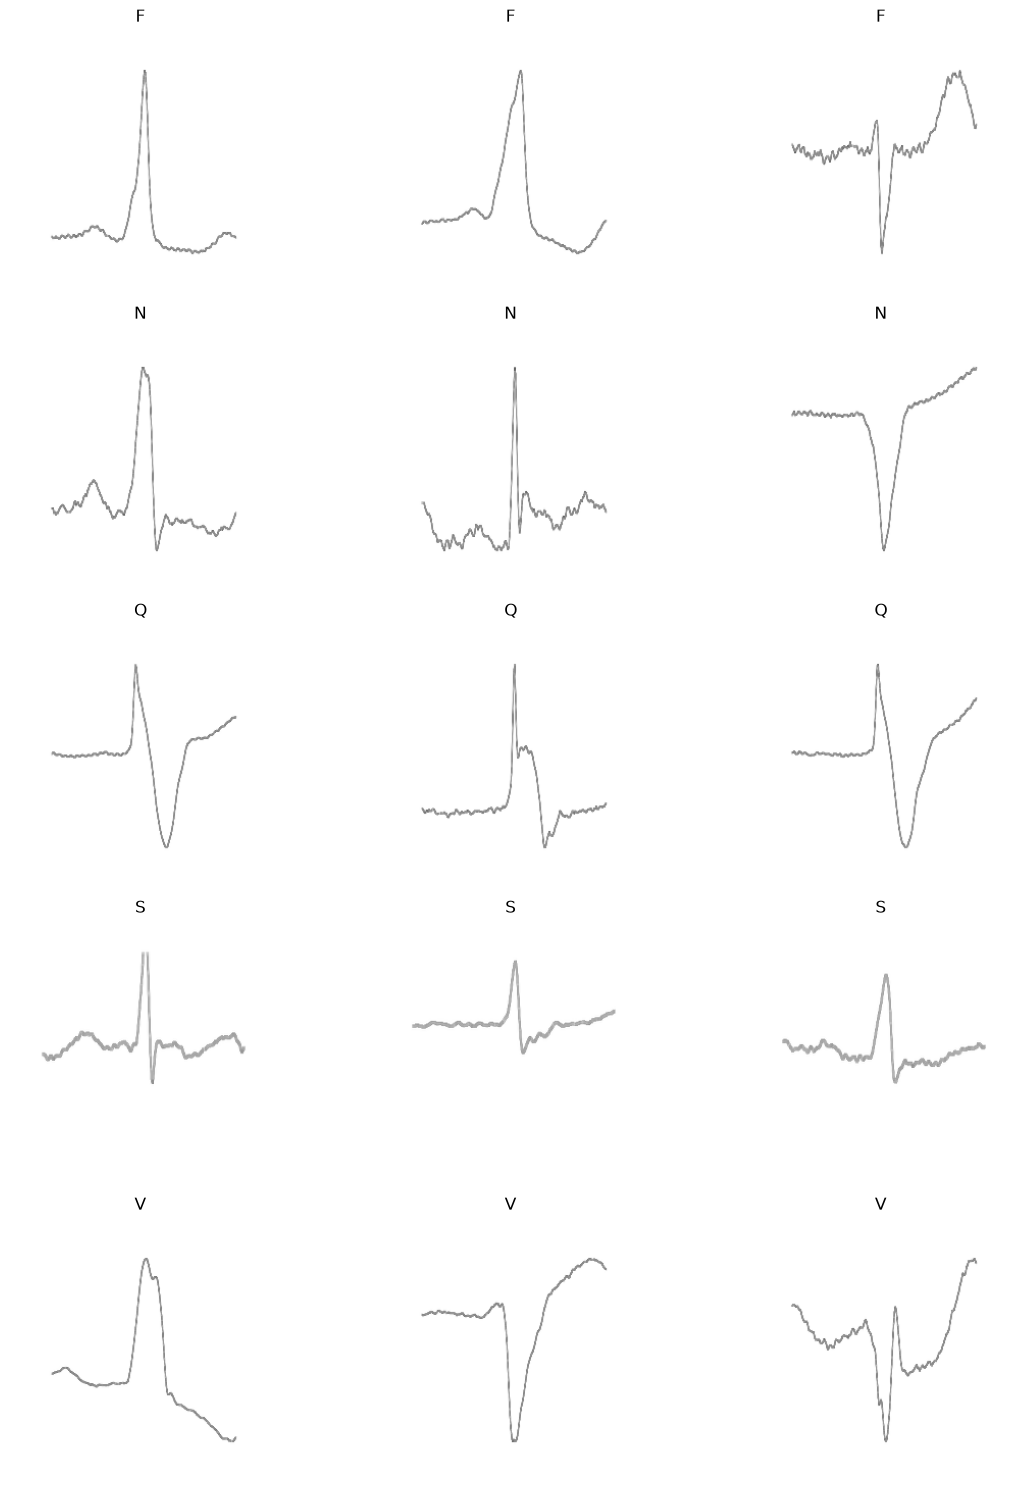

In [6]:
def get_images_recursive(class_dir: Path):
    return [
        f for f in Path(class_dir).rglob("*")
        if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS
    ]

def plot_samples(data_dir, classes, samples_per_class=3):
    data_dir = Path(data_dir)

    if len(classes) == 0:
        print("Nenhuma classe disponível para plotar.")
        return

    fig, axes = plt.subplots(
        len(classes),
        samples_per_class,
        figsize=(12, max(3, len(classes) * 3))
    )

    if len(classes) == 1:
        axes = np.array([axes])

    for i, cls in enumerate(classes):
        class_dir = data_dir / cls
        images = get_images_recursive(class_dir)
        selected = random.sample(images, min(samples_per_class, len(images)))

        for j in range(samples_per_class):
            ax = axes[i][j] if len(classes) > 1 else axes[0][j]

            if j < len(selected):
                img = Image.open(selected[j]).convert("RGB")
                ax.imshow(img)
                ax.set_title(cls)
            else:
                ax.set_title(f"{cls} - sem imagem")

            ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_samples(TRAIN_DIR, classes)

## 4. Análise de Distribuição de Classes — IR ALÉM 1

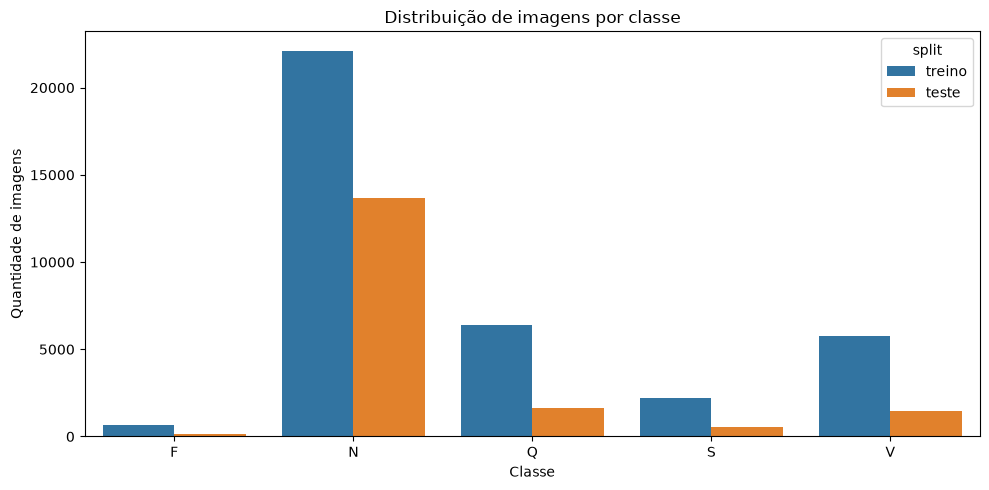

,classe,treino,teste
0,F,641,161
1,N,22122,13661
2,Q,6413,1608
3,S,2222,557
4,V,5780,1448


In [7]:
df_summary_plot = df_summary.melt(
    id_vars="classe",
    value_vars=["treino", "teste"],
    var_name="split",
    value_name="quantidade"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary_plot, x="classe", y="quantidade", hue="split")
plt.title("Distribuição de imagens por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=150)
plt.show()

df_summary

In [8]:
total_train = df_summary["treino"].sum()
df_summary["percentual_treino"] = (df_summary["treino"] / total_train * 100).round(2)

majority = df_summary["treino"].max()
minority = df_summary["treino"].min()
imbalance_ratio = round(majority / max(1, minority), 2)

print("Total treino:", total_train)
print("Razão de desbalanceamento maior/menor classe:", imbalance_ratio)
display(df_summary)

if imbalance_ratio > 2:
    print("\n⚠️ Atenção: há desbalanceamento relevante entre classes.")
    print("Mitigações possíveis: class_weight, data augmentation, amostragem balanceada e avaliação por classe.")
else:
    print("\n✓ Distribuição relativamente equilibrada.")

Total treino: 37178
Razão de desbalanceamento maior/menor classe: 34.51


,classe,treino,teste,percentual_treino
0,F,641,161,1.72
1,N,22122,13661,59.50
2,Q,6413,1608,17.25
3,S,2222,557,5.98
4,V,5780,1448,15.55



⚠️ Atenção: há desbalanceamento relevante entre classes.
Mitigações possíveis: class_weight, data augmentation, amostragem balanceada e avaliação por classe.


## 5. Preparação dos Dados

Para acelerar testes locais, este notebook pode criar uma cópia reduzida do dataset em `outputs/sample_dataset/`.

Se `USE_SMALL_DATASET = False`, o treino usa o dataset completo.

In [9]:
def copy_limited_dataset(source_dir: Path, target_dir: Path, max_images_per_class: int):
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    for cls in classes:
        src_class = source_dir / cls
        dst_class = target_dir / cls
        dst_class.mkdir(parents=True, exist_ok=True)

        images = get_images_recursive(src_class)
        selected = images[:max_images_per_class]

        for idx, img_path in enumerate(selected):
            dst_file = dst_class / f"{cls}_{idx:05d}{img_path.suffix.lower()}"
            shutil.copy2(img_path, dst_file)

    return target_dir

if USE_SMALL_DATASET:
    SAMPLE_ROOT = OUTPUT_DIR / "sample_dataset"
    SAMPLE_TRAIN_DIR = SAMPLE_ROOT / "train"
    SAMPLE_TEST_DIR = SAMPLE_ROOT / "test"

    print("Criando dataset reduzido para execução rápida...")

    copy_limited_dataset(TRAIN_DIR, SAMPLE_TRAIN_DIR, MAX_TRAIN_IMAGES_PER_CLASS)

    if TEST_DIR is not None:
        copy_limited_dataset(TEST_DIR, SAMPLE_TEST_DIR, MAX_TEST_IMAGES_PER_CLASS)
    else:
        SAMPLE_TEST_DIR = None

    TRAIN_SOURCE = SAMPLE_TRAIN_DIR
    TEST_SOURCE = SAMPLE_TEST_DIR
else:
    TRAIN_SOURCE = TRAIN_DIR
    TEST_SOURCE = TEST_DIR

print("TRAIN_SOURCE:", TRAIN_SOURCE)
print("TEST_SOURCE:", TEST_SOURCE)

Criando dataset reduzido para execução rápida...
TRAIN_SOURCE: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\sample_dataset\train
TEST_SOURCE: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\sample_dataset\test


In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_SOURCE,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_SOURCE,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

if TEST_SOURCE is not None and TEST_SOURCE.exists():
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_SOURCE,
        labels="inferred",
        label_mode="categorical",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
else:
    print("Pasta test não encontrada. Usando validação como teste apenas para demonstração.")
    test_ds = val_ds

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Número de classes:", num_classes)

Found 3000 files belonging to 5 classes.
Using 2400 files for training.
Found 3000 files belonging to 5 classes.
Using 600 files for validation.
Found 961 files belonging to 5 classes.
Classes: ['F', 'N', 'Q', 'S', 'V']
Número de classes: 5


In [11]:
# Normalização e performance do pipeline
normalization_layer = layers.Rescaling(1./255)

train_ds_norm = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_norm = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_norm = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds_norm = train_ds_norm.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_norm = val_ds_norm.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_norm = test_ds_norm.cache().prefetch(buffer_size=AUTOTUNE)

print("Pipelines de treino, validação e teste preparados.")

Pipelines de treino, validação e teste preparados.


## 6. CNN Simples Treinada do Zero

In [12]:
def build_simple_cnn(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_simple_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=EPOCHS_CNN,
    callbacks=[early_stop]
)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.2071 - loss: 1.6385 - val_accuracy: 0.2067 - val_loss: 1.5813
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.7275 - loss: 0.7895 - val_accuracy: 0.9067 - val_loss: 0.2897
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.9217 - loss: 0.2696 - val_accuracy: 0.9433 - val_loss: 0.1612
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step - accuracy: 0.9488 - loss: 0.1668 - val_accuracy: 0.9517 - val_loss: 0.1231
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - accuracy: 0.9671 - loss: 0.1115 - val_accuracy: 0.9617 - val_loss: 0.0943


In [14]:
cnn_model_path = MODEL_DIR / "cnn_ecg_model.keras"
cnn_model.save(cnn_model_path)

# Também salvar classes para o Flask/protótipo
classes_path = MODEL_DIR / "class_names.json"
with open(classes_path, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Modelo CNN salvo em:", cnn_model_path)
print("Classes salvas em:", classes_path)

Modelo CNN salvo em: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\models\cnn_ecg_model.keras
Classes salvas em: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\models\class_names.json


## 7. Transfer Learning com MobileNetV2

In [15]:
# Data augmentation simples
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# Para MobileNetV2, usamos preprocess_input em vez de Rescaling(1./255)
train_ds_tl = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_tl = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_tl = test_ds.map(lambda x, y: (preprocess_input(x), y))

train_ds_tl = train_ds_tl.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_tl = test_ds_tl.cache().prefetch(buffer_size=AUTOTUNE)

base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = tf.keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCHS_TRANSFER,
    callbacks=[early_stop]
)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.4854 - loss: 1.2739 - val_accuracy: 0.6850 - val_loss: 0.8298
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.7675 - loss: 0.7028 - val_accuracy: 0.8000 - val_loss: 0.5397
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.8388 - loss: 0.5020 - val_accuracy: 0.8000 - val_loss: 0.4908


In [17]:
transfer_model_path = MODEL_DIR / "transfer_mobilenetv2_ecg_model.keras"
transfer_model.save(transfer_model_path)

print("Modelo Transfer Learning salvo em:", transfer_model_path)

Modelo Transfer Learning salvo em: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\models\transfer_mobilenetv2_ecg_model.keras


## 8. Avaliação dos Modelos

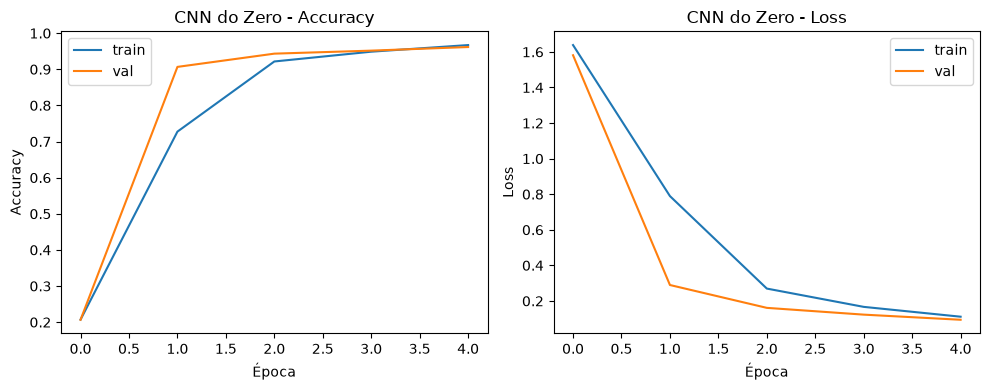

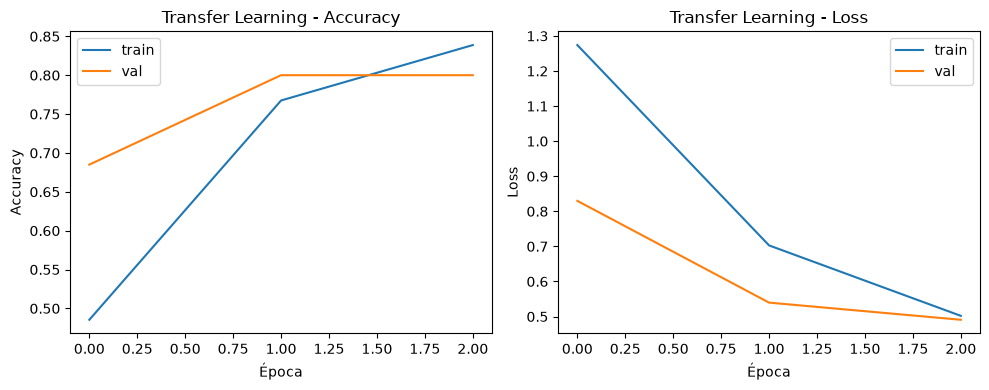

In [18]:
def plot_training_history(history, title, output_name):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist["accuracy"], label="train")
    plt.plot(hist["val_accuracy"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / output_name, dpi=150)
    plt.show()

plot_training_history(history_cnn, "CNN do Zero", "training_history_cnn.png")
plot_training_history(history_transfer, "Transfer Learning", "training_history_transfer.png")

CNN do Zero
Accuracy: 0.9459

Classification Report:
              precision    recall  f1-score   support

           F       0.94      0.92      0.93       161
           N       0.95      0.94      0.95       200
           Q       0.94      0.95      0.94       200
           S       0.98      0.96      0.97       200
           V       0.92      0.95      0.94       200

    accuracy                           0.95       961
   macro avg       0.95      0.94      0.95       961
weighted avg       0.95      0.95      0.95       961



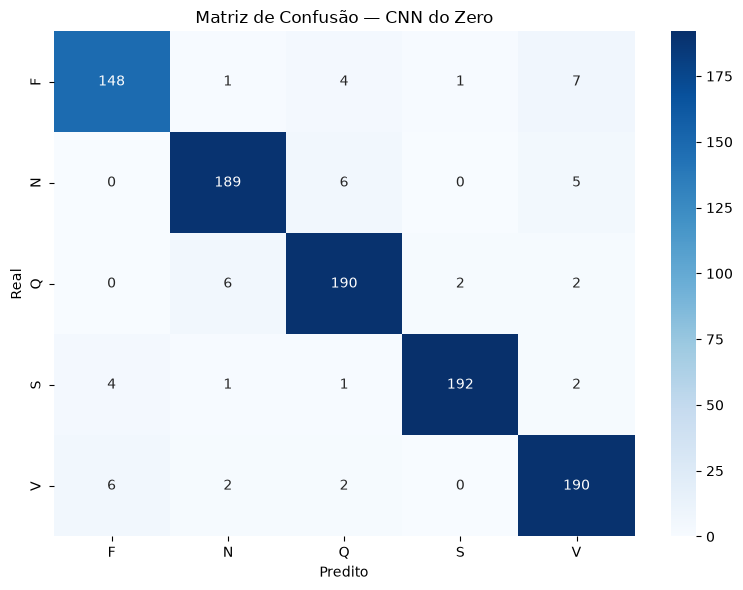

Transfer Learning MobileNetV2
Accuracy: 0.6764

Classification Report:
              precision    recall  f1-score   support

           F       0.94      0.83      0.88       161
           N       0.77      0.09      0.15       200
           Q       0.75      0.82      0.79       200
           S       0.93      0.77      0.84       200
           V       0.44      0.91      0.59       200

    accuracy                           0.68       961
   macro avg       0.77      0.68      0.65       961
weighted avg       0.76      0.68      0.64       961



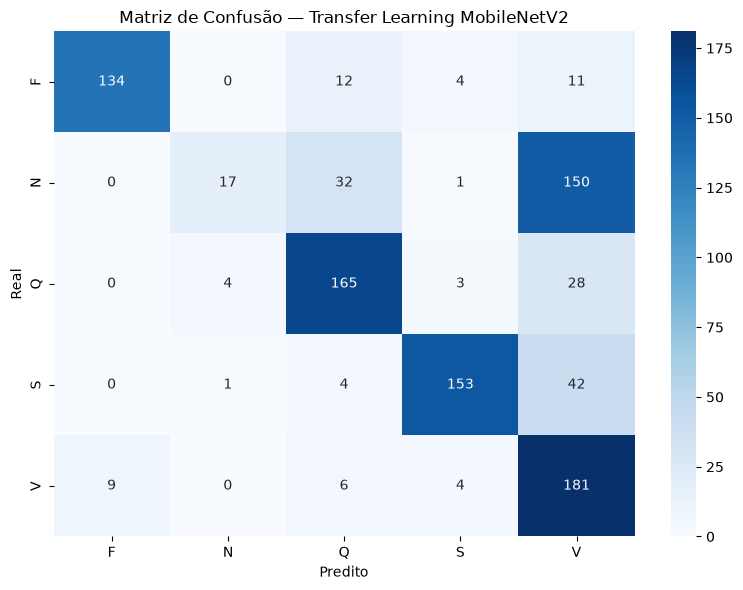

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,CNN do Zero,0.945890,0.946245,0.945890,0.945966
1,Transfer Learning MobileNetV2,0.676379,0.759018,0.676379,0.641056


Métricas salvas em: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\figures\model_metrics.csv


In [19]:
def get_predictions(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_prob.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def evaluate_model(model, dataset, class_names, title, output_prefix):
    y_true, y_pred, y_prob = get_predictions(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    print("=" * 80)
    print(title)
    print("=" * 80)
    print("Accuracy:", round(acc, 4))
    print("\nClassification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Matriz de Confusão — {title}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"confusion_matrix_{output_prefix}.png", dpi=150)
    plt.show()

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    metrics = {
        "model": title,
        "accuracy": float(acc),
        "precision_weighted": float(precision),
        "recall_weighted": float(recall),
        "f1_weighted": float(f1),
    }

    return metrics, report, cm

metrics_cnn, report_cnn, cm_cnn = evaluate_model(
    cnn_model,
    test_ds_norm,
    class_names,
    "CNN do Zero",
    "cnn"
)

metrics_transfer, report_transfer, cm_transfer = evaluate_model(
    transfer_model,
    test_ds_tl,
    class_names,
    "Transfer Learning MobileNetV2",
    "transfer"
)

df_metrics = pd.DataFrame([metrics_cnn, metrics_transfer])
display(df_metrics)

df_metrics.to_csv(FIGURE_DIR / "model_metrics.csv", index=False)
print("Métricas salvas em:", FIGURE_DIR / "model_metrics.csv")

## 9. Inferência em Imagem Individual

Imagem: C:\Users\JonasLuisdaSilva\Documents\GitHub\CardioAI\phases\fase04_cnn_ecg\outputs\sample_dataset\test\N\N_00135.png
Resultado: {'predicted_class': 'N', 'confidence': 0.9995434880256653, 'probabilities': {'F': 3.878166535287164e-05, 'N': 0.9995434880256653, 'Q': 2.3333743229159154e-05, 'S': 4.5479548134608194e-05, 'V': 0.0003488060610834509}}


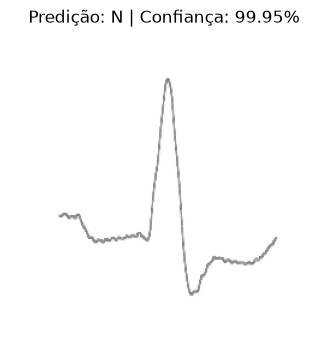

In [20]:
def predict_image_cnn(image_path, model, class_names, img_size=(128, 128)):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(img_size)

    arr = np.array(img_resized).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    return {
        "predicted_class": class_names[pred_idx],
        "confidence": float(probs[pred_idx]),
        "probabilities": {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    }

# Escolhe uma imagem qualquer do conjunto de teste/validação para demonstrar
demo_base = TEST_SOURCE if TEST_SOURCE is not None else TRAIN_SOURCE
demo_images = []

for cls in class_names:
    demo_images.extend(get_images_recursive(Path(demo_base) / cls))

demo_image = random.choice(demo_images)

result = predict_image_cnn(demo_image, cnn_model, class_names, IMG_SIZE)

print("Imagem:", demo_image)
print("Resultado:", result)

img = Image.open(demo_image).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Predição: {result['predicted_class']} | Confiança: {result['confidence']:.2%}")
plt.show()

## 10. Célula de Upload Manual — Colab

Use esta célula no Google Colab para enviar uma imagem individual e testar a predição.

In [21]:
# Execute no Google Colab se quiser testar upload manual.
# from google.colab import files
#
# uploaded = files.upload()
# for filename in uploaded.keys():
#     result = predict_image_cnn(filename, cnn_model, class_names, IMG_SIZE)
#     print("Arquivo:", filename)
#     print("Classe prevista:", result["predicted_class"])
#     print("Confiança:", f"{result['confidence']:.2%}")

## 11. Considerações de Governança e Ética — IR ALÉM 1

Pontos observados:

- Datasets públicos podem ter desbalanceamento entre classes.
- A performance média pode esconder baixo recall em classes raras.
- Em saúde, falso negativo pode ser mais grave que falso positivo.
- O modelo não deve ser usado como diagnóstico médico.
- É necessária validação clínica, revisão especializada e avaliação externa.
- A matriz de confusão e métricas por classe são essenciais para entender limitações.

Mitigações recomendadas:

- Balanceamento por classe ou `class_weight`.
- Data augmentation controlado.
- Validação em bases externas.
- Monitoramento contínuo de performance.
- Explicabilidade visual, por exemplo Grad-CAM, em evolução futura.
- Supervisão humana obrigatória.

## 12. Conclusão

A Fase 4 demonstrou um protótipo de Assistente Cardiológico Virtual com Visão Computacional, usando imagens simuladas/públicas de ECG.

Foram implementados:

- pipeline de pré-processamento;
- organização treino/validação/teste;
- CNN simples do zero;
- Transfer Learning com MobileNetV2;
- avaliação com métricas e matriz de confusão;
- inferência em imagem individual;
- análise de governança e limitações éticas.

O resultado é acadêmico e não substitui avaliação médica.